# SurvivalNet Demo

This notebook shows the basic workflow for loading clinical data, normalizing survival columns, fitting Kaplan-Meier and Cox models, and plotting grouped survival curves.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from survivalnet import CoxModel, fit_km, plot_grouped_km_with_pvalue, split_risk_group
from survivalnet.models import LassoCoxModel
from survivalnet.io import load_clinical_data, normalize_survival_data

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

data_path = None
for candidate in [
    Path("examples/data_clinical_patient.txt"),
    Path("data_clinical_patient.txt"),
    Path("../examples/data_clinical_patient.txt"),
]:
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("Could not find examples/data_clinical_patient.txt")

print(f"Using data file: {data_path.resolve()}")

Using data file: /home/zengj/bio2503/survivalnet/SurvivalNet/examples/data_clinical_patient.txt


In [2]:
# Load and normalize overall survival data.
raw_df = load_clinical_data(str(data_path))
data = normalize_survival_data(raw_df, "OS_MONTHS", "OS_STATUS", id_col="PATIENT_ID")

display(data[["PATIENT_ID", "duration", "event", "AGE", "KARNOFSKY_PERFORMANCE_SCORE"]].head())
print(f"Normalized rows: {len(data)}")

成功读取数据，原始矩阵形状为: (522, 79)
删失数据标准化完成：有效样本 513 例 (剔除了 9 例缺失值)


,PATIENT_ID,duration,event,AGE,KARNOFSKY_PERFORMANCE_SCORE
0,TCGA-05-4244,0.00,0,70,[Not Available]
1,TCGA-05-4245,23.98,0,81,[Not Available]
2,TCGA-05-4249,50.03,0,67,[Not Available]
3,TCGA-05-4250,3.98,1,79,[Not Available]
4,TCGA-05-4382,19.94,0,68,[Not Available]


Normalized rows: 513


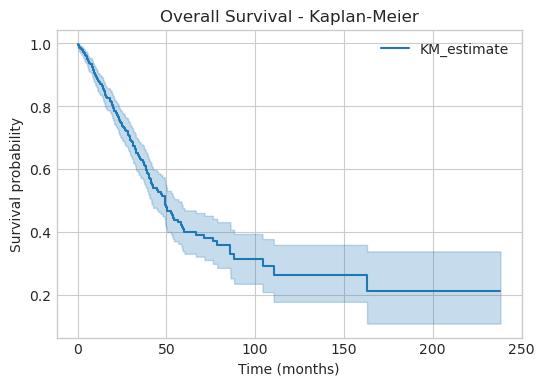

In [3]:
# Kaplan-Meier curve for the whole cohort.
kmf = fit_km(data, "duration", "event")
ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_title("Overall Survival - Kaplan-Meier")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival probability")
plt.show()

Rows used for Cox model: 503


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
AGE,0.008318,1.008352,0.007747,-0.006866,0.023501,0.993158,1.023779,0.0,1.073678,0.282967,1.821293


,HR,CI_lower,CI_upper,p_value
covariate,,,,
AGE,1.008352,0.993158,1.023779,0.282967


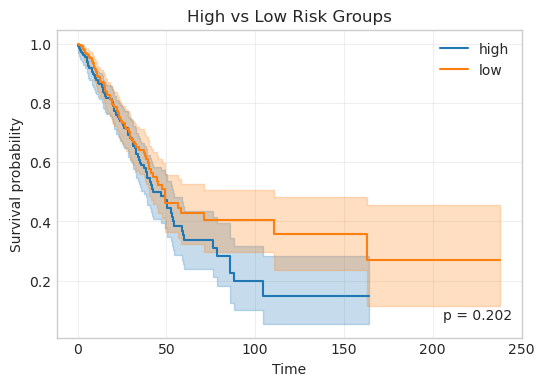

In [4]:
# Cox model demo using AGE as a stable numeric covariate.
cox_df = data[["duration", "event", "AGE"]].copy()
cox_df["AGE"] = pd.to_numeric(cox_df["AGE"], errors="coerce")
cox_df = cox_df.dropna()

print(f"Rows used for Cox model: {len(cox_df)}")

cox_model = CoxModel().fit(cox_df, "duration", "event")
display(cox_model.summary)
display(cox_model.hazard_ratios)

risk_scores = cox_model.predict_risk_score(cox_df)
cox_df["risk_group"] = split_risk_group(risk_scores)

ax = plot_grouped_km_with_pvalue(
    cox_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)
ax.set_title("High vs Low Risk Groups")
plt.show()

Rows used for LASSO-Cox model: 513
Features used: ['AGE', 'INITIAL_PATHOLOGIC_DX_YEAR', 'TOBACCO_SMOKING_HISTORY_INDICATOR', 'SMOKING_PACK_YEARS', 'SMOKING_YEAR_STARTED', 'SMOKING_YEAR_STOPPED', 'FEV1_PERCENT_REF_PREBRONCHOLIATOR', 'ECOG_SCORE', 'CARBON_MONOXIDE_DIFFUSION_DLCO', 'FEV1_FVC_RATIO_PREBRONCHOLIATOR', 'FEV1_PERCENT_REF_POSTBRONCHOLIATOR', 'FEV1_FVC_RATIO_POSTBRONCHOLIATOR', 'KARNOFSKY_PERFORMANCE_SCORE']
开始进行 LASSO-Cox 回归，当前 penalizer (lambda) = 0.1
LASSO 筛选完成！从 13 个原始特征中筛选出 0 个核心预后特征。
Selected features: []


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
AGE,7.861037e-09,1.0,0.000007,-0.000014,0.000014,0.999986,1.000014,0.0,0.001112,0.999113,0.001280
INITIAL_PATHOLOGIC_DX_YEAR,-4.423917e-08,1.0,0.000022,-0.000042,0.000042,0.999958,1.000042,0.0,-0.002054,0.998361,0.002366
TOBACCO_SMOKING_HISTORY_INDICATOR,3.860594e-08,1.0,0.000063,-0.000124,0.000124,0.999876,1.000124,0.0,0.000611,0.999513,0.000703
SMOKING_PACK_YEARS,3.117749e-09,1.0,0.000003,-0.000006,0.000006,0.999994,1.000006,0.0,0.001009,0.999195,0.001162
SMOKING_YEAR_STARTED,-1.754379e-09,1.0,0.000007,-0.000014,0.000014,0.999986,1.000014,0.0,-0.000244,0.999805,0.000281
SMOKING_YEAR_STOPPED,1.232178e-09,1.0,0.000007,-0.000013,0.000013,0.999987,1.000013,0.0,0.000180,0.999856,0.000208
FEV1_PERCENT_REF_PREBRONCHOLIATOR,-8.807114e-09,1.0,0.000005,-0.000010,0.000010,0.999990,1.000010,0.0,-0.001790,0.998572,0.002062
ECOG_SCORE,2.897201e-07,1.0,0.000165,-0.000324,0.000324,0.999676,1.000324,0.0,0.001753,0.998601,0.002019
CARBON_MONOXIDE_DIFFUSION_DLCO,-9.938990e-09,1.0,0.000006,-0.000011,0.000011,0.999989,1.000011,0.0,-0.001770,0.998588,0.002039


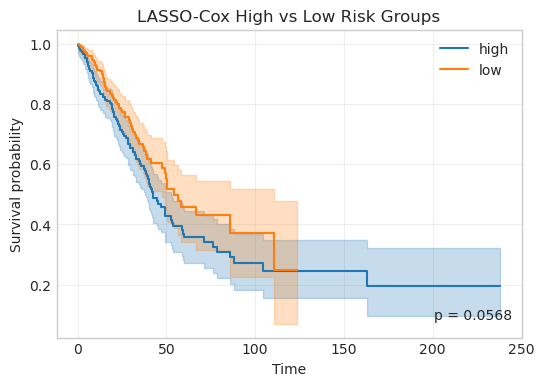

In [5]:
# LASSO-Cox demo using a stable numeric feature set.
# We keep columns with enough observed values, impute missing values by median,
# and then fit the extension module.

candidate_features = [
    "AGE",
    "INITIAL_PATHOLOGIC_DX_YEAR",
    "TOBACCO_SMOKING_HISTORY_INDICATOR",
    "SMOKING_PACK_YEARS",
    "SMOKING_YEAR_STARTED",
    "SMOKING_YEAR_STOPPED",
    "FEV1_PERCENT_REF_PREBRONCHOLIATOR",
    "ECOG_SCORE",
    "CARBON_MONOXIDE_DIFFUSION_DLCO",
    "FEV1_FVC_RATIO_PREBRONCHOLIATOR",
    "FEV1_PERCENT_REF_POSTBRONCHOLIATOR",
    "FEV1_FVC_RATIO_POSTBRONCHOLIATOR",
    "KARNOFSKY_PERFORMANCE_SCORE",
]

lasso_df = data[["duration", "event"]].copy()
used_features = []

for col in candidate_features:
    if col not in data.columns:
        continue
    series = pd.to_numeric(data[col], errors="coerce")
    if series.notna().sum() >= 50 and series.nunique(dropna=True) > 1:
        lasso_df[col] = series
        used_features.append(col)

if not used_features:
    raise ValueError("No usable numeric features found for the LASSO-Cox demo.")

for col in used_features:
    lasso_df[col] = lasso_df[col].fillna(lasso_df[col].median())

print(f"Rows used for LASSO-Cox model: {len(lasso_df)}")
print(f"Features used: {used_features}")

lasso_model = LassoCoxModel(penalizer=0.1).fit(lasso_df, "duration", "event")
selected_features = lasso_model.selected_features
print("Selected features:", selected_features)

display(lasso_model.fitter.summary)

lasso_risk_scores = lasso_model.predict_risk_score(lasso_df)
lasso_df["risk_group"] = split_risk_group(lasso_risk_scores)

ax = plot_grouped_km_with_pvalue(
    lasso_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)
ax.set_title("LASSO-Cox High vs Low Risk Groups")
plt.show()